In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/yolo v8"  # <-- CHANGE THIS

print("Files inside dataset folder:")
print(os.listdir(DATASET_PATH))

Files inside dataset folder:
['README.roboflow.txt', 'data.yaml', 'train']


In [ ]:
import os, shutil, random

# your dataset train path
train_images = DATASET_PATH + "/train/images"
train_labels = DATASET_PATH + "/train/labels"

val_images = DATASET_PATH + "/valid/images"
val_labels = DATASET_PATH + "/valid/labels"

os.makedirs(val_images, exist_ok=True)
os.makedirs(val_labels, exist_ok=True)

# list all images
images = os.listdir(train_images)
random.shuffle(images)

val_ratio = 0.2
val_count = int(len(images) * val_ratio)

moved_images_count = 0
moved_labels_count = 0

for img in images[:val_count]:
    label_filename = img.rsplit('.', 1)[0] + ".txt"

    src_image_path = os.path.join(train_images, img)
    src_label_path = os.path.join(train_labels, label_filename)

    # Check if image file exists before moving
    if not os.path.exists(src_image_path):
        print(f"Warning: Image file not found: {src_image_path}. Skipping.")
        continue

    # Check if label file exists before moving
    if not os.path.exists(src_label_path):
        print(f"Warning: Corresponding label file not found for image {img} at {src_label_path}. Moving image only.")
        shutil.move(src_image_path, os.path.join(val_images, img))
        moved_images_count += 1
        continue

    # If both exist, move both
    shutil.move(src_image_path, os.path.join(val_images, img))
    shutil.move(src_label_path, os.path.join(val_labels, label_filename))
    moved_images_count += 1
    moved_labels_count += 1

print("Validation split complete.")
print(f"Total images processed for validation split: {val_count}")
print(f"Images moved to val: {moved_images_count}")
print(f"Labels moved to val: {moved_labels_count}")

Validation split complete.
Total images processed for validation split: 203
Images moved to val: 203
Labels moved to val: 203


In [ ]:
yaml_path = DATASET_PATH + "/data.yaml"

with open(yaml_path, "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['emulsion', 'oil', 'oil-platform', 'sheen', 'ship']

roboflow:
  workspace: samirs-workspace-9uzpu
  project: samirs-workspace-9uzpu
  version: dataset
  license: Private
  url: https://app.roboflow.com/samirs-workspace-9uzpu/samirs-workspace-9uzpu/dataset


In [ ]:
yaml_content = f"""
train: {DATASET_PATH}/train/images
val: {DATASET_PATH}/valid/images

nc: 5
names: ['emulsion', 'oil', 'oil-platform', 'sheen', 'ship']
"""

with open(DATASET_PATH + "/data.yaml", "w") as f:
    f.write(yaml_content)

print("YAML fixed successfully!")

YAML fixed successfully!


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import torch

print("GPU:", torch.cuda.is_available())

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: True


In [ ]:
from ultralytics import YOLO

# Medium model = best accuracy for your dataset size
model = YOLO("yolov8m.pt")

results = model.train(
    data=DATASET_PATH + "/data.yaml",
    epochs=120,          # more epochs for small dataset
    imgsz=640,
    batch=16,

    # Optimizer & LR
    lr0=0.0008,          # lower LR for stability
    optimizer="AdamW",
    weight_decay=0.0005,

    # Augmentation (strong for small dataset)
    mosaic=1.0,
    mixup=0.1,
    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.4,
    flipud=0.5,
    fliplr=0.5,
    degrees=12,
    translate=0.15,
    scale=0.6,
    shear=0.1,
    perspective=0.001,

    # Early stopping
    patience=25
)

print("TRAINING STARTED…")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolo v8/data.yaml, degrees=12, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0008, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, 

In [ ]:
!ls /content/drive/MyDrive/yolo v8

ls: cannot access '/content/drive/MyDrive/yolo': No such file or directory
ls: cannot access 'v8': No such file or directory


In [ ]:
from ultralytics import YOLO
model = YOLO("/content/runs/detect/train/weights/best.pt")
model.info()

Model summary: 170 layers, 25,859,215 parameters, 0 gradients, 79.1 GFLOPs


(170, 25859215, 0, 79.07850239999999)

In [ ]:
results = model("/content/Screenshot 2026-04-19 163640.png", save=True)


image 1/1 /content/Screenshot 2026-04-19 163640.png: 384x640 2 emulsions, 1 ship, 359.7ms
Speed: 9.4ms preprocess, 359.7ms inference, 11.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


In [ ]:
results = model(
    "/content/Screenshot 2026-04-19 163640.png",
    conf=0.25,   # confidence threshold
    iou=0.7      # better box filtering
)


image 1/1 /content/Screenshot 2026-04-19 163640.png: 384x640 2 emulsions, 1 ship, 25.0ms
Speed: 2.5ms preprocess, 25.0ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)



image 1/1 /content/Screenshot 2026-04-19 163640.png: 384x640 2 emulsions, 1 ship, 37.0ms
Speed: 4.4ms preprocess, 37.0ms inference, 8.4ms postprocess per image at shape (1, 3, 384, 640)


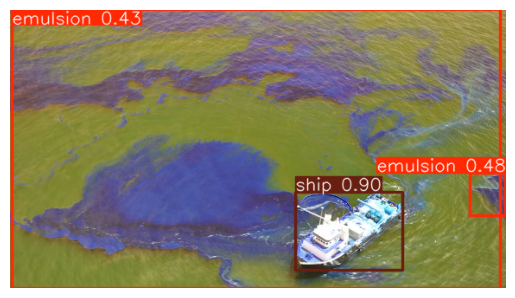

In [ ]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

# Load best model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Run prediction
results = model("/content/Screenshot 2026-04-19 163640.png")

# Display image with boxes
for r in results:
    im_array = r.plot()  # draws boxes + labels + confidence
    plt.imshow(im_array)
    plt.axis('off')
    plt.show()

Saving Screenshot 2026-04-19 164054.png to Screenshot 2026-04-19 164054.png

image 1/1 /content/Screenshot 2026-04-19 164054.png: 352x640 1 oil, 1 ship, 74.9ms
Speed: 2.3ms preprocess, 74.9ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)


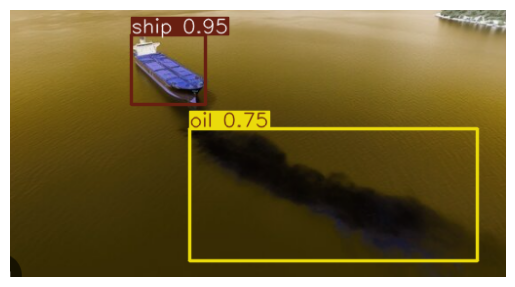

In [ ]:
from google.colab import files
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load your best model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Upload image
uploaded = files.upload()

# Get uploaded file name automatically
image_path = list(uploaded.keys())[0]

# Run prediction
results = model(image_path)

# Show image with boxes
for r in results:
    im_array = r.plot()
    plt.imshow(im_array)
    plt.axis('off')
    plt.show()